<a href="https://colab.research.google.com/github/wilsonkatam9/Sentiment-analysis-IMBD/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
!pip install datasets scikit-learn matplotlib seaborn wordcloud pandas numpy --quiet


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

In [50]:
# Load IMDb dataset (50,000 movie reviews)
dataset = load_dataset('imdb')

train_df = pd.DataFrame(dataset['train'])
test_df  = pd.DataFrame(dataset['test'])

# Map labels: 0 = Negative, 1 = Positive
label_map = {0: 'Negative', 1: 'Positive'}
train_df['sentiment'] = train_df['label'].map(label_map)
test_df['sentiment']  = test_df['label'].map(label_map)

print(f"Training samples: {len(train_df)}")
print(f"Testing  samples: {len(test_df)}")
train_df.head(3)

Training samples: 25000
Testing  samples: 25000


,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,Negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,Negative
2,If only to avoid making this type of film in t...,0,Negative


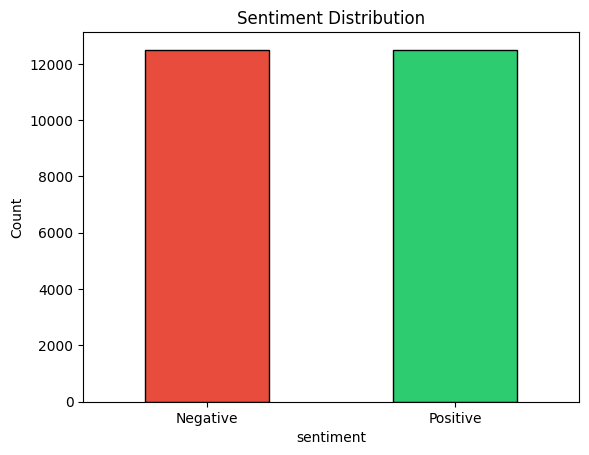

In [51]:
# Check class balance
train_df['sentiment'].value_counts().plot(
    kind='bar', color=['#e74c3c','#2ecc71'],
    title='Sentiment Distribution', edgecolor='black'
)
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.show()

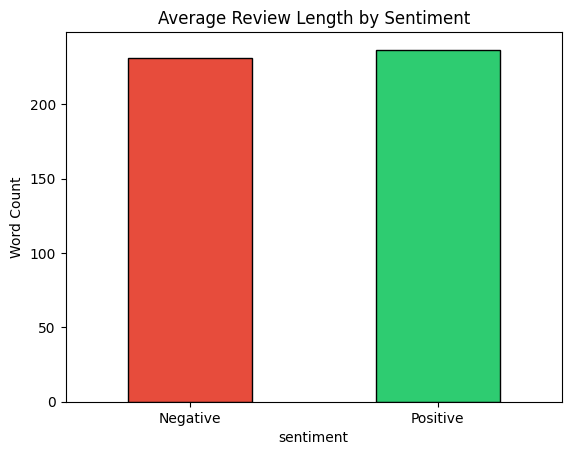

In [52]:
# Review length analysis
train_df['review_length'] = train_df['text'].apply(lambda x: len(x.split()))

train_df.groupby('sentiment')['review_length'].mean().plot(
    kind='bar', color=['#e74c3c','#2ecc71'],
    title='Average Review Length by Sentiment', edgecolor='black'
)
plt.xticks(rotation=0)
plt.ylabel("Word Count")
plt.show()

In [53]:
import re

def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'<.*?>', '', text)            # remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text)         # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra spaces
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text']  = test_df['text'].apply(clean_text)

print("Text cleaned!")
print(train_df['clean_text'][0][:300])

Text cleaned!
i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by us customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to see th


In [54]:

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words=None,
    min_df=2
)

X_train = vectorizer.fit_transform(train_df['clean_text'])
X_test  = vectorizer.transform(test_df['clean_text'])

y_train = train_df['label']
y_test  = test_df['label']

print(" Vectorization done!", X_train.shape)

 Vectorization done! (25000, 20000)


In [55]:
# ---- Logistic Regression ----
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_acc   = accuracy_score(y_test, lr_preds)
print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")

Logistic Regression Accuracy: 89.26%


In [56]:
# ----  Naive Bayes ----
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)
nb_acc   = accuracy_score(y_test, nb_preds)
print(f"Naive Bayes Accuracy: {nb_acc*100:.2f}%")

Naive Bayes Accuracy: 86.48%


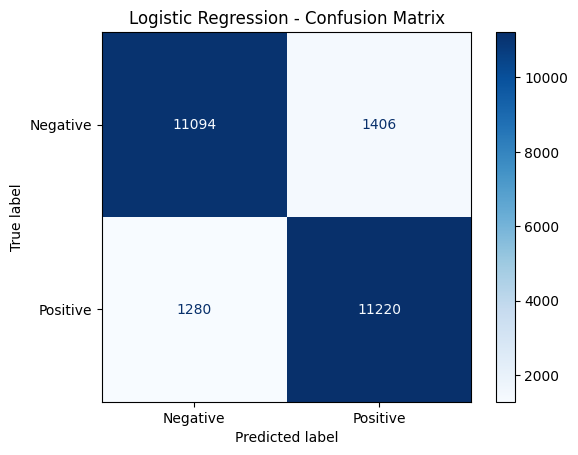

              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89     12500
    Positive       0.89      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



In [57]:
# Confusion Matrix for best model (LR)
cm = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative','Positive'])
disp.plot(cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test, lr_preds, target_names=['Negative','Positive']))

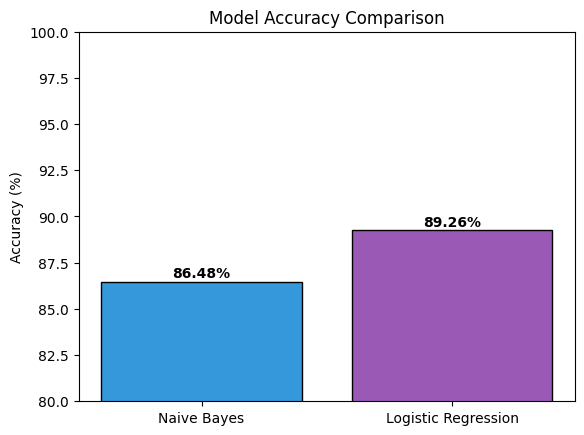

In [58]:
# Model Comparison Bar Chart
models = ['Naive Bayes', 'Logistic Regression']
scores = [nb_acc * 100, lr_acc * 100]

plt.bar(models, scores, color=['#3498db','#9b59b6'], edgecolor='black')
plt.ylim(80, 100)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for i, v in enumerate(scores):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

In [59]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = lr_model.predict(vectorized)[0]
    return "✅ Positive" if prediction == 1 else "❌ Negative"

print(predict_sentiment("This movie was absolutely amazing! I loved every moment."))
print(predict_sentiment("Terrible film. Complete waste of time and money."))
print(predict_sentiment("The plot was okay but the acting was brilliant."))
print(predict_sentiment("Not a good movie"))

✅ Positive
❌ Negative
❌ Negative
❌ Negative
